Notebook 4: Evaluation of BERT and the LLM

This notebook scores the stored repairs of the three methods and compares them:

- **BERT (fine-tuned)**: `bert-base-cased` fine-tuned on clean text, filling the slots left to right with a
  letter-similarity reranking (notebook 2);
- **few-shot**: Qwen3 30B A3B Instruct with the instruction, 5 solved examples and the sentence with numbered
  slots (notebook 3);
- **few-shot + article**: the same with the whole article as context (notebook 3). Only compared with the
  LLM's own few-shot result: BERT sees the sentence only, so this variant is not part of the BERT
  comparison.

BERT and few-shot get exactly the same sentence (BERT the plain slot view, the LLM the same view with numbered
slots) and are scored on exactly the same rows. The damaged text itself ("no repair") is scored the same way
as a reference.

**Input.** `data/processed/corrupted_v2.jsonl` (hash checked), the stored predictions in `runs/preds/`
(nothing is sent to a model here), `configs/llm.yaml` for the few-shot examples.

**Output.** The tables and the figure below.

`SPLIT` chooses the rows. It is `dev` here, where the numbers are used to choose settings and are not the
result of the study. A variant is scored only when all of its rows for the split are stored.

In [1]:
import hashlib
import json
import time

import pandas as pd
import transformers
from bert_score import BERTScorer
from rapidfuzz.distance import Levenshtein

from blnrepair.data import ROOT, load_config
from blnrepair.freeze import load_frozen
from blnrepair.bert_repair import load_repair_config, repair_version
from blnrepair.llm import load_llm_config, variant_versions
from blnrepair.plots import level_lines
from blnrepair.preds import load_preds, pred_path, slot_exact
from blnrepair.slots import build_slots, slot_core, slot_view, splice

transformers.logging.set_verbosity_error()
pd.set_option("display.max_colwidth", None)
config, llm_config = load_config(), load_llm_config()
rows = load_frozen("v2")  # stops if the file hash does not match runs/corrupted_v2.sha256
by_key = {(r["id"], r["severity"]): r for r in rows}
LEVELS = ["1w", "10", "25", "50", "75"]
SPLIT = "dev"

D:\UR_Lectures\GenAI_proj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


What is scored

The rows are every row of the split that has slots (level 0 is the clean sentence), without the 5
sentences shown as few-shot examples: their gold answers are in the prompt. On the test split this leaves
nothing out, because the examples are dev sentences and dev and test share no excerpt. Below, how many rows
each method has stored.

In [2]:
example_ids = {i for i, _ in llm_config["fewshot_picks"]}
scored_rows = [r for r in rows if r["split"] == SPLIT and r["id"] not in example_ids and r["k"]]
scored_ids = sorted({r["id"] for r in scored_rows})
expected = {(r["id"], r["severity"]) for r in scored_rows}

versions = variant_versions(llm_config, SPLIT)
VARIANTS = {"BERT (fine-tuned)": ("bert_rerank", repair_version(load_repair_config(), SPLIT)),  # written by notebook 2
            "few-shot": versions["few-shot"], "few-shot + article": versions["few-shot + article"]}
ORDER = list(VARIANTS)  # fixed order: a method keeps its colour in every figure
stored = {name: {(p["id"], p["severity"]): p for p in load_preds(pred_path(*v))} for name, v in VARIANTS.items()}
available = [name for name in VARIANTS if expected <= set(stored[name])]
METHODS = available + ["no repair"]
print(f"{len(scored_ids)} sentences, {len(expected)} rows per method in the {SPLIT} split")
pd.DataFrame({"rows stored": {n: len(expected & set(s)) for n, s in stored.items()},
              "rows needed": len(expected), "scored": {n: n in available for n in stored}})

15 sentences, 75 rows per method in the dev split


,rows stored,rows needed,scored
BERT (fine-tuned),75,75,True
few-shot,75,75,True
few-shot + article,75,75,True


The scores

All scores are per sentence and level, over the damaged span unless stated (dossier §8):

- **BERTScore of the span** (primary): F1 between the repaired span and the gold span, with `roberta-large`
  and the package's baseline rescaling (so unrelated text scores near 0 and identical text 1).
- **Fact Recovery Rate** (primary): share of the span's fact tokens restored exactly in their slot
  (punctuation around the word ignored).
- **Exact words**: share of slots restored exactly.
- **CER before / after and repair gain**: character error rate of the span against the gold span, for
  the damaged text and for the repair; gain = before minus after (positive = the repair helped).
- **BERTScore of the sentence** (secondary): the same for the whole sentence.

A format failure (the LLM answered with the wrong number of words) is scored as **no repair**: its slots
count as wrong, and its text is the damaged text.

In [3]:
def span_row(row):
    # the row cut to its damaged span, so that splice builds the span text only
    s, e = row["span_start"], row["span_end"]
    return {"gold_tokens": row["gold_tokens"][s:e], "ops_per_word": [{**p, "idx": p["idx"] - s} for p in row["ops_per_word"]]}


def row_scores(row, pred_words):
    plans = sorted(row["ops_per_word"], key=lambda p: p["idx"])
    ok = pred_words is not None
    words = pred_words if ok else [p["out"] for p in plans]
    gold_span = " ".join(row["gold_tokens"][row["span_start"]:row["span_end"]])
    damaged_span, repaired_span = splice(span_row(row), [p["out"] for p in plans]), splice(span_row(row), words)
    facts = [slot_core(w) == slot_core(p["gold"]) for w, p in zip(words, plans) if p["idx"] in row["fact_idx_in_span"]]
    cer = lambda text: Levenshtein.distance(text, gold_span) / len(gold_span)
    return {"format_ok": ok, "gold span": gold_span, "damaged span": damaged_span, "repaired span": repaired_span,
            "repaired sentence": splice(row, words), "exact": slot_exact(pred_words, row),
            "fact recovery": sum(facts) / len(facts) if ok else 0.0,
            "CER before": cer(damaged_span), "CER after": cer(repaired_span)}


def multiword_count(p):
    # LLM rows keep a dict with the positions of multi-word answers; BERT rows keep a list of candidates
    raw = json.loads(p["raw_output"])
    return len(raw["multiword"]) if isinstance(raw, dict) else 0


records = []
for name in available:
    for key in sorted(expected):
        p, row = stored[name][key], by_key[key]
        records.append({"method": name, "id": key[0], "level": key[1], "band": row["band"],
                        "multiword": multiword_count(p),
                        **row_scores(row, p["pred_words"])})
for key in sorted(expected):
    records.append({"method": "no repair", "id": key[0], "level": key[1], "band": by_key[key]["band"],
                    "multiword": 0, **row_scores(by_key[key], None), "format_ok": True})
scores = pd.DataFrame(records)
scores["repair gain"] = scores["CER before"] - scores["CER after"]
scores["format failure"] = ~scores["format_ok"]

In [4]:
scorer = BERTScorer(model_type="roberta-large", lang="en", rescale_with_baseline=True)
t0 = time.perf_counter()
scores["BERTScore span"] = scorer.score(list(scores["repaired span"]), list(scores["gold span"]))[2].numpy()
gold_sentence = {r["id"]: r["gold_text"] for r in scored_rows}
scores["BERTScore sentence"] = scorer.score(list(scores["repaired sentence"]), [gold_sentence[i] for i in scores["id"]])[2].numpy()
print(f"BERTScore for {len(scores)} spans and sentences in {time.perf_counter() - t0:.0f} s")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   3%|▎         | 13/389 [00:00<00:04, 92.36it/s]

Loading weights:   6%|▌         | 23/389 [00:00<00:14, 24.89it/s]

Loading weights:   7%|▋         | 28/389 [00:01<00:18, 19.40it/s]

Loading weights:   8%|▊         | 32/389 [00:01<00:23, 15.28it/s]

...

Loading weights:  19%|█▊        | 72/389 [00:03<00:13, 22.85it/s]

Loading weights:  19%|█▉        | 75/389 [00:03<00:15, 20.62it/s]

Loading weights: 100%|██████████| 389/389 [00:03<00:00, 103.11it/s]

D:\UR_Lectures\GenAI_proj\.venv\Lib\site-packages\bert_score\scorer.py:139: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self._baseline_vals = torch.from_numpy(


BERTScore for 300 spans and sentences in 185 s


Results

Means per method and level:

In [5]:
columns = ["BERTScore span", "fact recovery", "exact", "CER before", "CER after", "repair gain", "BERTScore sentence"]
means = scores.groupby(["method", "level"])[columns].mean().reindex(pd.MultiIndex.from_product([METHODS, LEVELS]))
means.round(3)

BERTScore span  fact recovery  exact  CER before  \
BERT (fine-tuned)  1w           0.593          0.133  0.133       0.289   
                   10           0.384          0.167  0.409       0.309   
                   25           0.159          0.089  0.269       0.291   
                   50           0.135          0.050  0.219       0.298   
                   75          -0.032          0.037  0.178       0.299   
few-shot           1w           0.858          0.600  0.600       0.289   
                   10           0.652          0.467  0.682       0.309   
                   25           0.452          0.417  0.546       0.291   
                   50           0.439          0.461  0.576       0.298   
                   75           0.174          0.374  0.393       0.299   
few-shot + article 1w           0.903          0.733  0.733       0.289   
                   10           0.631          0.500  0.649       0.309   
                   25           0.550          0.567  0.602       0.291   
                   50           0.421          0.500  0.560       0.298   
                   75           0.260          0.421  0.424       0.299   
no repair          1w           0.338          0.000  0.000       0.289   
                   10           0.014          0.000  0.000       0.309   
                   25          -0.161          0.000  0.000       0.291   
                   50          -0.268          0.000  0.000       0.298   
                   75          -0.340          0.000  0.000       0.299   

                       CER after  repair gain  BERTScore sentence  
BERT (fine-tuned)  1w      0.554       -0.265               0.956  
                   10      0.493       -0.184               0.892  
                   25      0.574       -0.283               0.680  
                   50      0.593       -0.296               0.468  
                   75      0.659       -0.360               0.169  
few-shot           1w      0.152        0.138               0.987  
                   10      0.207        0.102               0.943  
                   25      0.217        0.075               0.813  
                   50      0.232        0.066               0.646  
                   75      0.223        0.076               0.329  
few-shot + article 1w      0.185        0.104               0.991  
                   10      0.221        0.088               0.939  
                   25      0.221        0.070               0.840  
                   50      0.212        0.085               0.643  
                   75      0.236        0.063               0.395  
no repair          1w      0.289        0.000               0.911  
                   10      0.309        0.000               0.781  
                   25      0.291        0.000               0.507  
                   50      0.298        0.000               0.187  
                   75      0.299        0.000              -0.104

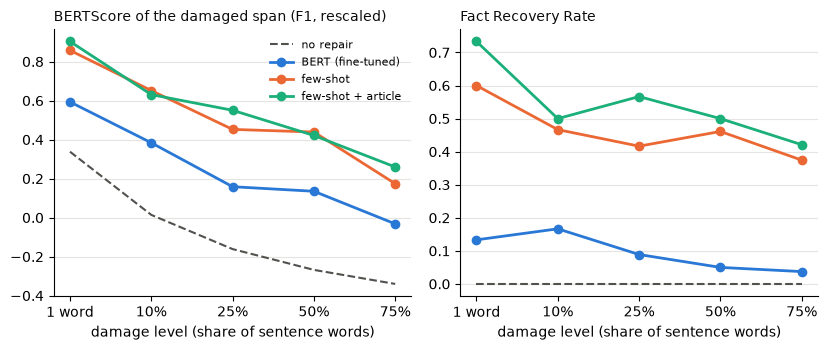

In [6]:
fig = level_lines(means, ["BERTScore span", "fact recovery"],
                  ["BERTScore of the damaged span (F1, rescaled)", "Fact Recovery Rate"], ORDER)

Format failures and multi-word answers per method (a format failure is scored as no repair), and the mean
over all levels:

In [7]:
scores[scores["method"] != "no repair"].groupby("method", sort=False).agg(
    rows=("exact", "size"), format_failures=("format failure", "sum"), multiword=("multiword", "sum"),
    **{c: (c, "mean") for c in ["BERTScore span", "fact recovery", "exact", "repair gain"]}).round(3)

,rows,format_failures,multiword,BERTScore span,fact recovery,exact,repair gain
method,,,,,,,
BERT (fine-tuned),75,0,0,0.248,0.095,0.242,-0.277
few-shot,75,7,1,0.515,0.464,0.559,0.091
few-shot + article,75,7,0,0.553,0.544,0.594,0.082


By level and length band (BERTScore of the span, mean): separates the share of damaged words from the
absolute length of the damaged span.

In [8]:
scores.pivot_table(index=["method", "level"], columns="band", values="BERTScore span", aggfunc="mean") \
      .reindex(pd.MultiIndex.from_product([METHODS, LEVELS])).round(3)

band                   20-29  30-44  45-60
BERT (fine-tuned)  1w  0.574  0.690  0.373
                   10  0.488  0.289  0.305
                   25  0.152  0.141  0.233
                   50  0.141  0.135  0.117
                   75  0.003 -0.084  0.002
few-shot           1w  0.889  0.871  0.708
                   10  0.808  0.459  0.681
                   25  0.350  0.560  0.488
                   50  0.422  0.562  0.131
                   75  0.142  0.228  0.126
few-shot + article 1w  0.919  0.950  0.708
                   10  0.703  0.509  0.744
                   25  0.518  0.632  0.418
                   50  0.382  0.586  0.065
                   75  0.339  0.188  0.199
no repair          1w  0.254  0.453  0.287
                   10  0.071 -0.037 -0.030
                   25 -0.098 -0.214 -0.226
                   50 -0.238 -0.289 -0.308
                   75 -0.293 -0.374 -0.399

**Paired comparisons.** Every sentence is repaired at every level by every method, so the methods are compared sentence by
sentence: the mean difference (first minus second) and how many sentences were better, equal or worse.
**BERT against few-shot** is the main comparison; both get the same sentence-only input. **Few-shot +
article against few-shot** shows whether the article helps the LLM; it is not a BERT comparison.

In [9]:
def paired(a, b, metric):
    wide = scores[scores["method"].isin([a, b])].pivot_table(index=["level", "id"], columns="method", values=metric)
    diff = (wide[a] - wide[b]).rename("diff").reset_index()
    return diff.groupby("level").agg(mean_diff=("diff", "mean"), better=("diff", lambda d: (d > 1e-9).sum()),
                                     same=("diff", lambda d: (d.abs() <= 1e-9).sum()),
                                     worse=("diff", lambda d: (d < -1e-9).sum())).reindex(LEVELS)


def paired_table(a, b):
    if {a, b} - set(available):
        print(f"{a} against {b}: not scored yet ({', '.join(sorted({a, b} - set(available)))} has no complete run)")
        return None
    return pd.concat({m: paired(a, b, m) for m in ["BERTScore span", "fact recovery"]}, axis=1).round(3)


for a, b in [("BERT (fine-tuned)", "few-shot"), ("few-shot + article", "few-shot")]:
    table = paired_table(a, b)
    if table is not None:
        display(table)

BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w            -0.264      1    2    12        -0.467      0    8     7
10            -0.268      4    0    11        -0.300      2    6     7
25            -0.294      3    0    12        -0.328      2    4     9
50            -0.304      3    0    12        -0.411      2    3    10
75            -0.206      6    0     9        -0.337      2    3    10

BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w             0.046      3   11     1         0.133      3   11     1
10            -0.021      6    5     4         0.033      2   12     1
25             0.098      9    0     6         0.150      6    7     2
50            -0.018      7    2     6         0.039      3   11     1
75             0.086      7    5     3         0.047      3   12     0

**Contamination probe.** The share of near-verbatim continuations of the LLM's probe (notebook 3): a high share would mean the LLM
results may be inflated.

In [10]:
probe = pd.DataFrame([json.loads(p["raw_output"]) for p in load_preds(pred_path(*versions["probe"]))])
print(f"probe on {len(probe)} {SPLIT} sentences: {probe['near_verbatim'].sum()} near-verbatim "
      f"({probe['near_verbatim'].mean():.0%}); similarity median {probe['similarity'].median():.2f}, max {probe['similarity'].max():.2f}")

probe on 20 dev sentences: 0 near-verbatim (0%); similarity median 0.25, max 0.31


Manual check

18 repairs (6 sentences at levels 10, 25 and 50, drawn with the project seed) for reading by hand, to find
repairs that are fluent but wrong.

In [11]:
rank = lambda i: hashlib.sha256(f"{config['seed']}-manual-{i}".encode()).hexdigest()
manual_ids = sorted(scored_ids, key=rank)[:6]
look = scores[scores["id"].isin(manual_ids) & scores["level"].isin(["10", "25", "50"])]
look.pivot_table(index=["id", "level", "gold span", "damaged span"], columns="method", values="repaired span", aggfunc="first") \
    [available].reset_index().drop(columns="id")

method,level,gold span,damaged span,BERT (fine-tuned),few-shot,few-shot + article
0,10,"No. 12, Market-place, Oxford-street, on","Uo. NIaruet-plece, Oforcl-sbteet, an","No. 5 Easts-place, Oxford-street, on","No. of Marlborough-place, Oxford-street, and","No. at Marylebone, Oxford-street, and"
1,25,"occupier of a house, No. 12, Market-place, Oxford-street, on the site of the","ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af","house of a coner, No. 9 ands-place, Oxford-street, and that it was the","occupant of the house, Uo. of Marlet-place, Oxford-street, and the site of the","occupier of the house, No. of Marlborough-place, Oxford-street, and the site of the"
2,50,"years past the prisoner was the occupier of a house, No. 12, Market-place, Oxford-street, on the site of the old Oxford-street Market, and complaints were","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte","years past he wased ined to the post of theroner, No. 9 ands-lane, Cromwell-street, and the same inquiry was madelyrned on-Thursday last, and noquiries were","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte"
3,10,"mother, Ellen Bean.","mather, Elen Besn.","father, John Beau.","mother, Ellen Benson.","mother, Ellen Beane."
4,25,"bank notes from his mother, Ellen Bean.","bana trom hi mather, Elen Besn.","a publichouse atrom s se, Pen green.","bana trom hi mather, Elen Besn.","bank notes from his mother, Eleanor Beane."
5,50,"tried and convicted of stealing £140 in bank notes from his mother, Ellen Bean.","trled ald ef stoalinb £l40 ii bana trom hi mather, Elen Besn.","charged with havingelonio andnionio stealing £10 in a publichouse atrom s thee, aten street.","tried said that he was £stealing £140 in the from his mother, Elen Benson.","tried and found guilty of £stealing £140 in the from his mother, Elen Beau."
6,10,"bicycle for £2, and","icyclc tor £1, aud","bicycless for £1s, and","bicycle for £100, and","bicycle for £1, and"
7,25,"sold the bicycle for £2, and then came to","so1d tbe icyclc tor £1, aud bhen eame bo","had been inly worth £1s, and then wased to","sold the cycle for £1, and then came to","sold the bicycle for £1, and then came to"
8,50,"where, it was asserted, he sold the bicycle for £2, and then came to London with the money.","It wae assetod, e so1d tbe icyclc tor £1, aud bhen eame bo Loidou witb tbe nioney.","where he was aed, and had been finedly fined £1s, and he wased to his wife by thene.","and it was assessed, he sold the bicycle for £1, and then came to London with the money.","and it was assessed, he sold the bicycle for £1, and then came to London with the money."
9,10,Southend Railway-station the,Southon Raiiy-ststion bhe,station in-Kentston the,Southampton Railway-station the,Southend Railway-station the
